# Olist Brazilian E-Commerce — Analytics Dashboard

**Source:** `our-project-93971.Extracted_data_star`  
**Tables:** `fact_order_items`, `fact_orders`, `dim_customers`, `dim_products`, `dim_sellers`, `dim_dates`

Single-run notebook: loads all data from BigQuery and renders a multi-panel dashboard.
Output is also saved to `../docs/dashboard.png`.

In [1]:
from google.cloud import bigquery
from matplotlib.patches import Patch
import matplotlib.gridspec as gridspec
import matplotlib.ticker as mticker
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', font_scale=0.9)

PROJECT = 'our-project-93971'
DATASET = 'Extracted_data_star'
client  = bigquery.Client(project=PROJECT)
print('BigQuery client ready.')

E0000 00:00:1781757519.127749   44117 instrument.cc:563] Metric with name 'grpc.resource_quota.calls_dropped' registered more than once. Ignoring later registration.
E0000 00:00:1781757519.128432   44117 instrument.cc:563] Metric with name 'grpc.resource_quota.calls_rejected' registered more than once. Ignoring later registration.
E0000 00:00:1781757519.128439   44117 instrument.cc:563] Metric with name 'grpc.resource_quota.connections_dropped' registered more than once. Ignoring later registration.
E0000 00:00:1781757519.128442   44117 instrument.cc:563] Metric with name 'grpc.resource_quota.instantaneous_memory_pressure' registered more than once. Ignoring later registration.
E0000 00:00:1781757519.128444   44117 instrument.cc:563] Metric with name 'grpc.resource_quota.memory_pressure_control_value' registered more than once. Ignoring later registration.


BigQuery client ready.


In [2]:
def q(sql):
    return client.query(sql).to_dataframe()

# ── KPIs ─────────────────────────────────────────────────────────────────────
kpis = q(f"""
    SELECT
        ROUND(SUM(total_payment_value), 0)                               AS total_revenue,
        COUNT(*)                                                         AS total_orders,
        ROUND(AVG(review_score), 2)                                      AS avg_review_score,
        ROUND(
            COUNTIF(delivery_days <= estimated_delivery_days)
            / NULLIF(COUNTIF(delivery_days IS NOT NULL), 0) * 100, 1
        )                                                                AS pct_on_time
    FROM `{PROJECT}.{DATASET}.fact_orders`
""")

# ── Monthly revenue & order volume ────────────────────────────────────────────
monthly = q(f"""
    SELECT
        d.year, d.month,
        COUNT(DISTINCT f.order_id)       AS order_count,
        ROUND(SUM(f.total_item_cost), 0) AS total_revenue
    FROM `{PROJECT}.{DATASET}.fact_order_items` f
    JOIN `{PROJECT}.{DATASET}.dim_dates` d ON f.purchase_date = d.date_id
    GROUP BY d.year, d.month
    ORDER BY d.year, d.month
""")
monthly['period'] = (
    monthly['year'].astype(str) + '-' +
    monthly['month'].astype(str).str.zfill(2)
)

# ── Top 10 product categories by revenue ─────────────────────────────────────
top_cats = q(f"""
    SELECT
        p.category_name_english,
        ROUND(SUM(f.total_item_cost), 0) AS total_revenue
    FROM `{PROJECT}.{DATASET}.fact_order_items` f
    JOIN `{PROJECT}.{DATASET}.dim_products` p ON f.product_id = p.product_id
    GROUP BY p.category_name_english
    ORDER BY total_revenue DESC
    LIMIT 10
""")

# ── Revenue by customer state (top 10) ───────────────────────────────────────
STATE_NAMES = {
    'SP': 'São Paulo',         'RJ': 'Rio de Janeiro',  'MG': 'Minas Gerais',
    'RS': 'Rio Grande do Sul', 'PR': 'Paraná',          'SC': 'Santa Catarina',
    'BA': 'Bahia',             'DF': 'Distrito Federal','GO': 'Goiás',
    'ES': 'Espírito Santo',    'PE': 'Pernambuco',      'CE': 'Ceará',
    'PA': 'Pará',              'MT': 'Mato Grosso',     'MA': 'Maranhão',
}
rev_state = q(f"""
    SELECT
        c.state,
        ROUND(SUM(o.total_payment_value), 0) AS total_revenue,
        COUNT(DISTINCT o.order_id)            AS total_orders
    FROM `{PROJECT}.{DATASET}.fact_orders` o
    JOIN `{PROJECT}.{DATASET}.dim_customers` c ON o.customer_id = c.customer_id
    GROUP BY c.state
    ORDER BY total_revenue DESC
    LIMIT 10
""")
rev_state['state_label'] = rev_state['state'].map(
    lambda s: f"{STATE_NAMES.get(s, s)} ({s})"
)

# ── Review score distribution ─────────────────────────────────────────────────
review_dist = q(f"""
    SELECT review_score, COUNT(*) AS cnt
    FROM `{PROJECT}.{DATASET}.fact_orders`
    WHERE review_score IS NOT NULL
    GROUP BY review_score
    ORDER BY review_score
""")

# ── Order status distribution ─────────────────────────────────────────────────
status_dist = q(f"""
    SELECT order_status, COUNT(*) AS cnt
    FROM `{PROJECT}.{DATASET}.fact_orders`
    GROUP BY order_status
    ORDER BY cnt DESC
""")

# ── % late deliveries by review score ────────────────────────────────────────
delivery_review = q(f"""
    SELECT
        review_score,
        ROUND(
            COUNTIF(delivery_days > estimated_delivery_days)
            / COUNT(*) * 100, 1
        ) AS pct_late
    FROM `{PROJECT}.{DATASET}.fact_orders`
    WHERE delivery_days IS NOT NULL
      AND estimated_delivery_days IS NOT NULL
      AND review_score IS NOT NULL
    GROUP BY review_score
    ORDER BY review_score
""")

print('All data loaded.')

All data loaded.


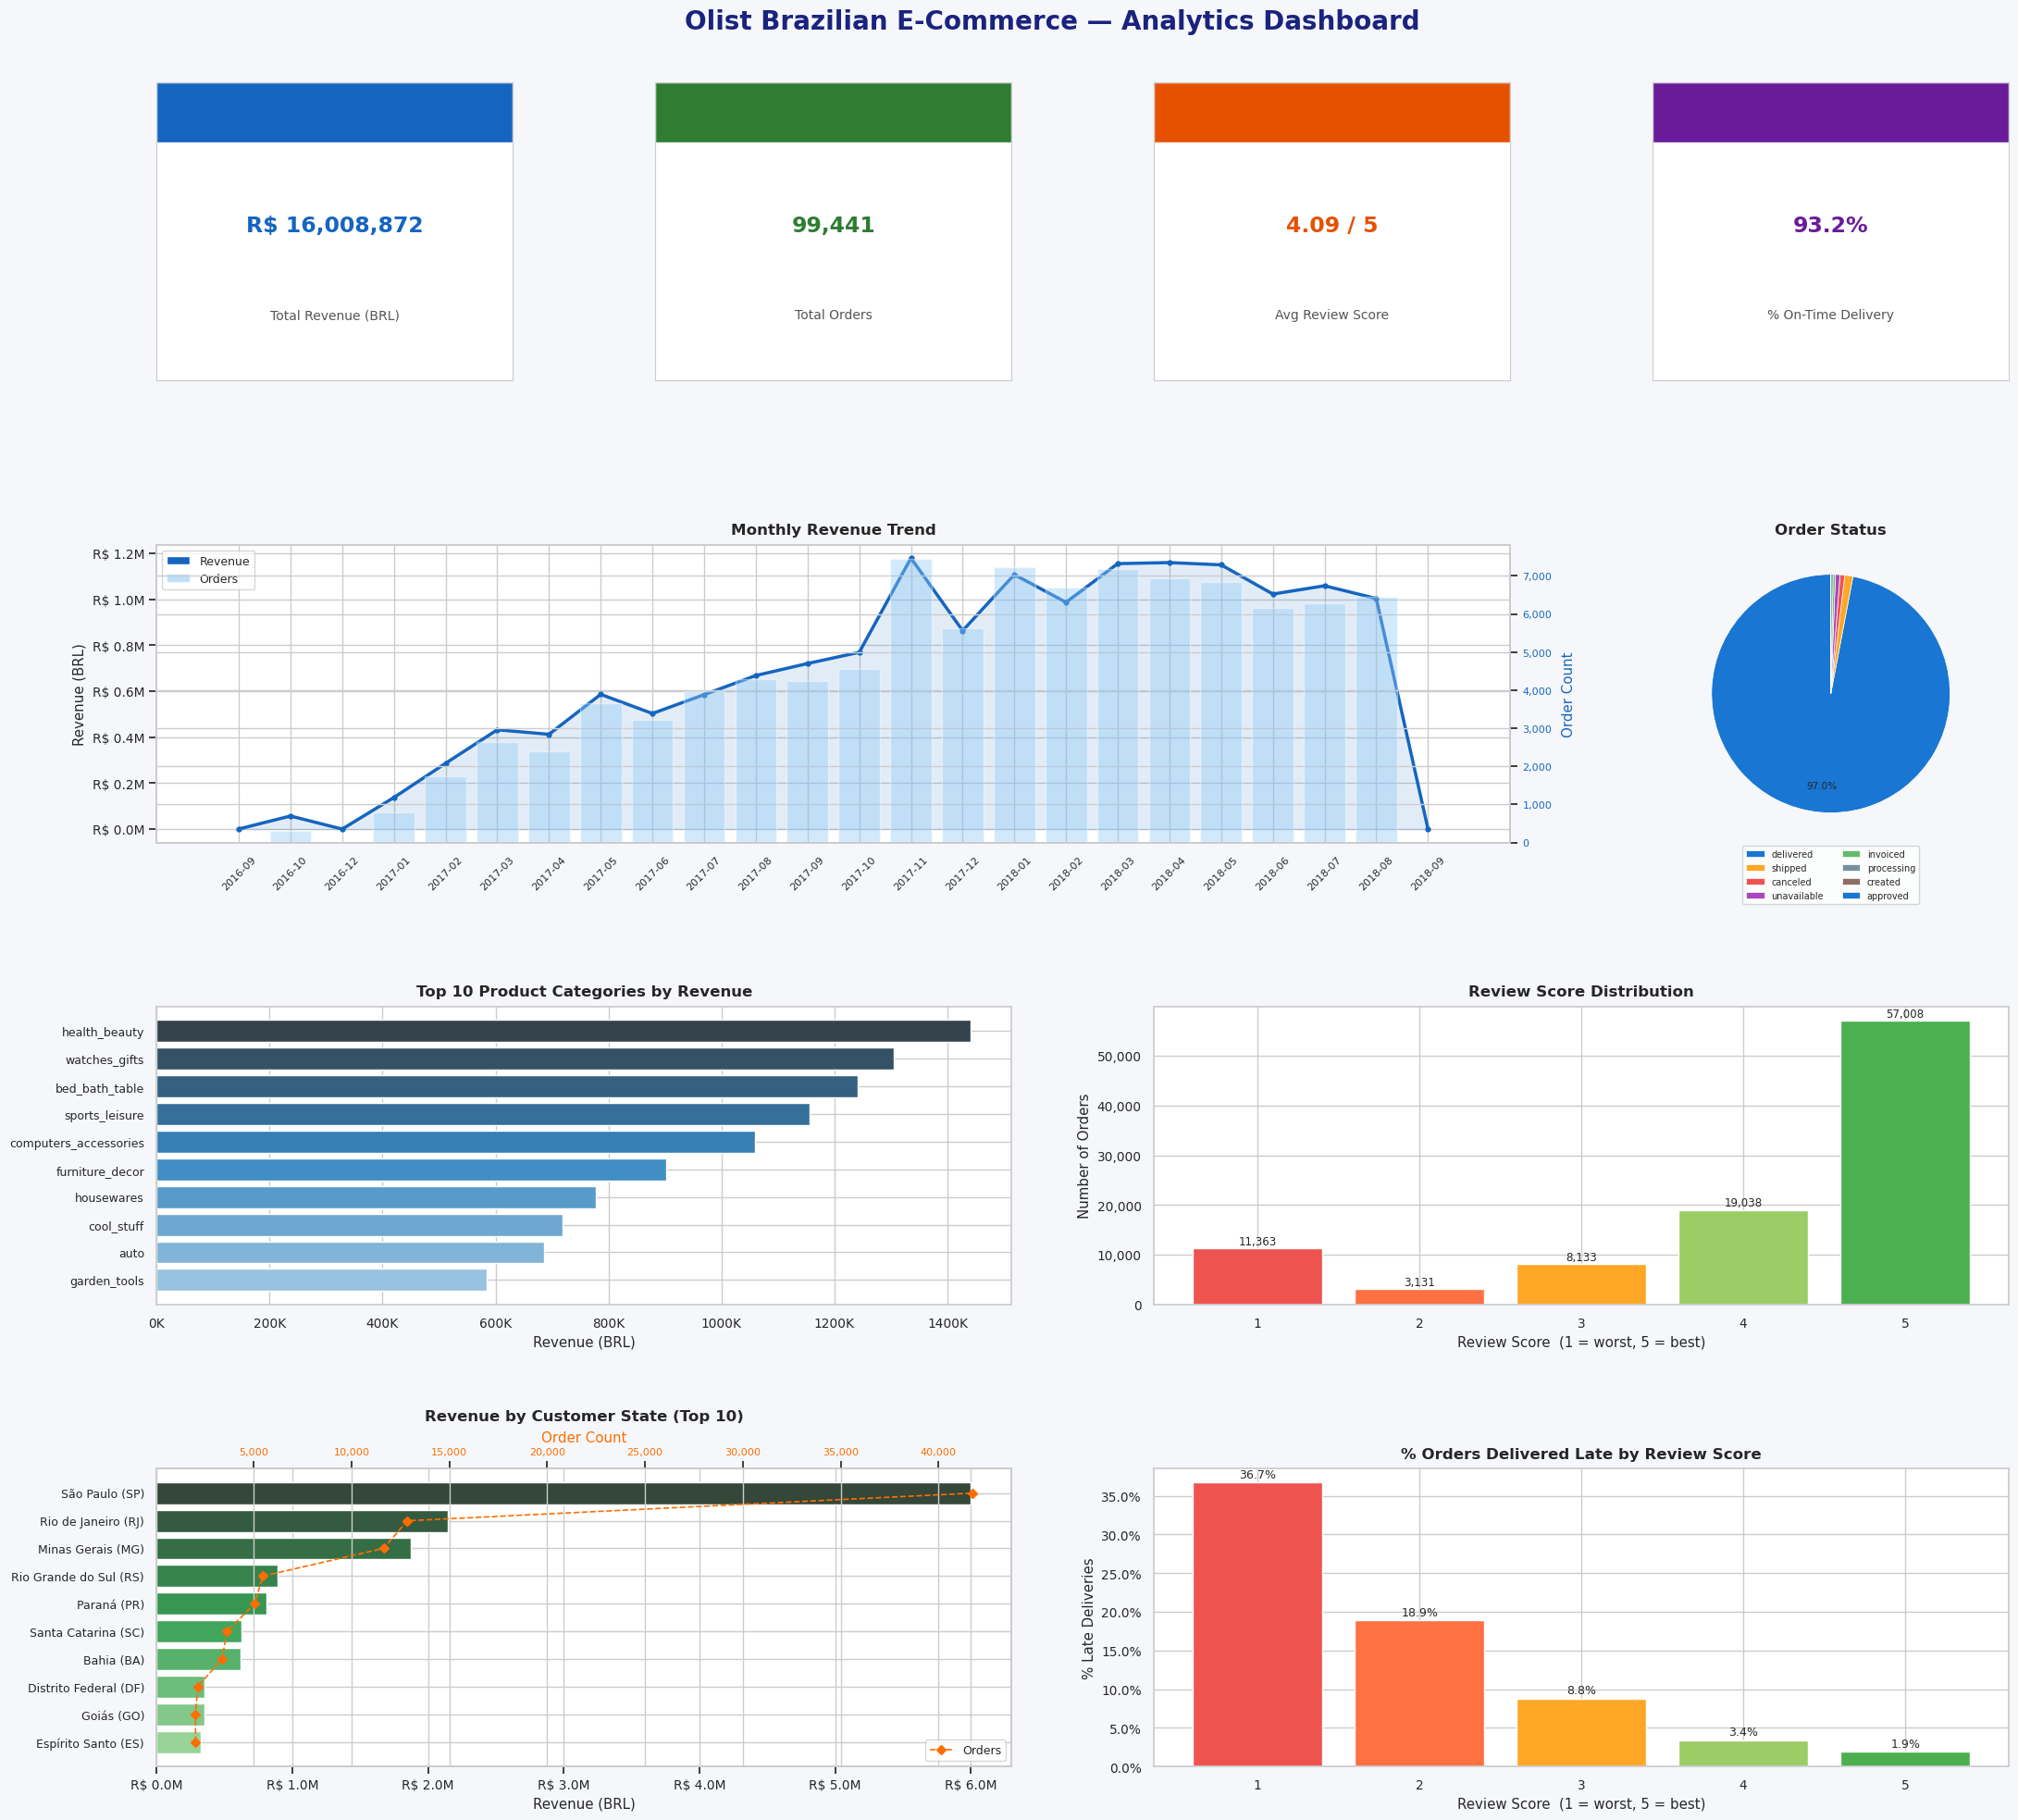

Dashboard saved to docs/dashboard.png


In [3]:
BG           = '#F5F7FA'
SCORE_COLORS = ['#EF5350', '#FF7043', '#FFA726', '#9CCC65', '#4CAF50']

fig = plt.figure(figsize=(22, 20))
fig.patch.set_facecolor(BG)
fig.suptitle(
    'Olist Brazilian E-Commerce — Analytics Dashboard',
    fontsize=20, fontweight='bold', y=0.99, color='#1A237E'
)

gs = gridspec.GridSpec(
    4, 4, figure=fig,
    hspace=0.55, wspace=0.40,
    top=0.95, bottom=0.04, left=0.06, right=0.97
)

# ── Row 0: KPI tiles ─────────────────────────────────────────────────────────
kpi_rows = [
    ('Total Revenue (BRL)', f"R$ {kpis['total_revenue'].iloc[0]:,.0f}",    '#1565C0'),
    ('Total Orders',        f"{kpis['total_orders'].iloc[0]:,}",            '#2E7D32'),
    ('Avg Review Score',    f"{kpis['avg_review_score'].iloc[0]:.2f} / 5", '#E65100'),
    ('% On-Time Delivery',  f"{kpis['pct_on_time'].iloc[0]:.1f}%",         '#6A1B9A'),
]
for i, (label, value, color) in enumerate(kpi_rows):
    ax = fig.add_subplot(gs[0, i])
    ax.set_facecolor('white')
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_edgecolor('#CCCCCC')
        spine.set_linewidth(0.8)
    ax.axhspan(0.80, 1.0, facecolor=color, alpha=1.0)
    ax.text(0.5, 0.52, value,
            ha='center', va='center', fontsize=17, fontweight='bold',
            color=color, transform=ax.transAxes)
    ax.text(0.5, 0.22, label,
            ha='center', va='center', fontsize=10,
            color='#555555', transform=ax.transAxes)

# ── Row 1: Monthly trend (3 cols) + Order status pie (1 col) ─────────────────
ax_t = fig.add_subplot(gs[1, 0:3])
ax_t.set_facecolor('white')
ax_t.plot(monthly['period'], monthly['total_revenue'],
          color='#1565C0', linewidth=2.5, marker='o', markersize=3.5)
ax_t.fill_between(monthly['period'], monthly['total_revenue'],
                  alpha=0.12, color='#1565C0')
ax_t.set_title('Monthly Revenue Trend', fontsize=12, fontweight='bold', pad=8)
ax_t.set_ylabel('Revenue (BRL)')
ax_t.tick_params(axis='x', rotation=45, labelsize=8)
ax_t.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'R$ {x/1e6:.1f}M')
)

ax_tv = ax_t.twinx()
ax_tv.bar(monthly['period'], monthly['order_count'],
          color='#90CAF9', alpha=0.4)
ax_tv.set_ylabel('Order Count', color='#1565C0', labelpad=8)
ax_tv.tick_params(axis='y', labelcolor='#1565C0', labelsize=8)
ax_tv.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{int(x):,}')
)

ax_t.legend(
    handles=[
        Patch(facecolor='#1565C0', label='Revenue'),
        Patch(facecolor='#90CAF9', alpha=0.6, label='Orders'),
    ],
    loc='upper left', fontsize=9
)

ax_s = fig.add_subplot(gs[1, 3])
ax_s.set_facecolor('white')
status_colors = ['#1976D2','#FFA726','#EF5350','#AB47BC','#66BB6A','#78909C','#8D6E63']
_, _, autotexts = ax_s.pie(
    status_dist['cnt'],
    autopct=lambda p: f'{p:.1f}%' if p > 2 else '',
    colors=status_colors[:len(status_dist)],
    startangle=90,
    pctdistance=0.78,
    wedgeprops={'linewidth': 0.5, 'edgecolor': 'white'},
)
for at in autotexts:
    at.set_fontsize(7.5)
ax_s.set_title('Order Status', fontsize=12, fontweight='bold', pad=8)
ax_s.legend(
    status_dist['order_status'],
    loc='lower center', bbox_to_anchor=(0.5, -0.22),
    ncol=2, fontsize=7
)

# ── Row 2: Top categories (2 cols) + Review score dist (2 cols) ──────────────
ax_c = fig.add_subplot(gs[2, 0:2])
ax_c.set_facecolor('white')
ax_c.barh(
    top_cats['category_name_english'][::-1],
    top_cats['total_revenue'][::-1],
    color=sns.color_palette('Blues_d', 10)
)
ax_c.set_title('Top 10 Product Categories by Revenue',
               fontsize=12, fontweight='bold', pad=8)
ax_c.set_xlabel('Revenue (BRL)')
ax_c.xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}K')
)
ax_c.tick_params(axis='y', labelsize=9)

ax_r = fig.add_subplot(gs[2, 2:4])
ax_r.set_facecolor('white')
bars = ax_r.bar(
    review_dist['review_score'].astype(str),
    review_dist['cnt'],
    color=SCORE_COLORS[:len(review_dist)]
)
ax_r.set_title('Review Score Distribution',
               fontsize=12, fontweight='bold', pad=8)
ax_r.set_xlabel('Review Score  (1 = worst, 5 = best)')
ax_r.set_ylabel('Number of Orders')
ax_r.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{int(x):,}')
)
for bar, cnt in zip(bars, review_dist['cnt']):
    ax_r.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 150,
        f'{cnt:,}', ha='center', va='bottom', fontsize=8.5
    )

# ── Row 3: Revenue by state (2 cols) + % late by review score (2 cols) ───────
ax_st = fig.add_subplot(gs[3, 0:2])
ax_st.set_facecolor('white')
ax_st.barh(
    rev_state['state_label'][::-1],
    rev_state['total_revenue'][::-1],
    color=sns.color_palette('Greens_d', 10)
)
ax_st.set_title('Revenue by Customer State (Top 10)',
                fontsize=12, fontweight='bold', pad=8)
ax_st.set_xlabel('Revenue (BRL)')
ax_st.xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'R$ {x/1e6:.1f}M')
)
ax_st.tick_params(axis='y', labelsize=9)

ax_st2 = ax_st.twiny()
ax_st2.plot(
    rev_state['total_orders'][::-1],
    rev_state['state_label'][::-1],
    'D--', color='#FF6D00', markersize=5, linewidth=1.2, label='Orders'
)
ax_st2.set_xlabel('Order Count', color='#FF6D00')
ax_st2.tick_params(axis='x', labelcolor='#FF6D00', labelsize=8)
ax_st2.xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{int(x):,}')
)
ax_st2.legend(loc='lower right', fontsize=9)

ax_d = fig.add_subplot(gs[3, 2:4])
ax_d.set_facecolor('white')
ax_d.bar(
    delivery_review['review_score'].astype(str),
    delivery_review['pct_late'],
    color=SCORE_COLORS[:len(delivery_review)]
)
ax_d.set_title('% Orders Delivered Late by Review Score',
               fontsize=12, fontweight='bold', pad=8)
ax_d.set_xlabel('Review Score  (1 = worst, 5 = best)')
ax_d.set_ylabel('% Late Deliveries')
ax_d.yaxis.set_major_formatter(mticker.PercentFormatter())
for i, (_, row) in enumerate(delivery_review.iterrows()):
    ax_d.text(
        i, row['pct_late'] + 0.3,
        f"{row['pct_late']:.1f}%",
        ha='center', va='bottom', fontsize=9
    )

plt.savefig('../docs/dashboard.png', dpi=150, bbox_inches='tight',
            facecolor=BG, edgecolor='none')
plt.show()
print('Dashboard saved to docs/dashboard.png')

In [ ]:
import os
import json

DATASET_EXTRACTED = 'Extracted_data'

queries_export = {
    'KPI': f"""
        SELECT
          ROUND(SUM(total_payment_value),2) AS total_revenue,
          COUNT(DISTINCT order_id) AS total_orders,
          ROUND(AVG(CAST(review_score AS FLOAT64)),2) AS avg_review,
          ROUND(COUNTIF(delivery_days <= estimated_delivery_days) * 100.0 /
            COUNTIF(delivery_days IS NOT NULL AND estimated_delivery_days IS NOT NULL),1) AS pct_on_time
        FROM `{PROJECT}.{DATASET_EXTRACTED}.fact_orders1`
        WHERE review_score IS NOT NULL
    """,
    'STATE_DATA': f"""
        WITH state_metrics AS (
          SELECT c.state,
            COUNT(DISTINCT o.order_id) AS total_orders,
            ROUND(SUM(o.total_payment_value),2) AS total_revenue,
            ROUND(AVG(CAST(o.review_score AS FLOAT64)),2) AS avg_review,
            ROUND(COUNTIF(o.delivery_days <= o.estimated_delivery_days) * 100.0 /
              COUNTIF(o.delivery_days IS NOT NULL AND o.estimated_delivery_days IS NOT NULL),1) AS pct_on_time
          FROM `{PROJECT}.{DATASET_EXTRACTED}.fact_orders1` o
          JOIN `{PROJECT}.{DATASET_EXTRACTED}.dim1_customers` c ON o.customer_id=c.customer_id
          GROUP BY c.state),
        seller_counts AS (
          SELECT state, COUNT(DISTINCT seller_id) AS seller_count
          FROM `{PROJECT}.{DATASET_EXTRACTED}.dim1_sellers` GROUP BY state),
        state_ref AS (
          SELECT * FROM UNNEST([
            STRUCT('AC' AS state,-9.0238 AS lat,-70.812 AS lng,'Acre' AS state_name),
            STRUCT('AL',-9.5713,-36.782,'Alagoas'),STRUCT('AM',-3.4168,-65.8561,'Amazonas'),
            STRUCT('AP',1.4102,-51.7703,'Amapá'),STRUCT('BA',-13.0506,-39.5625,'Bahia'),
            STRUCT('CE',-5.4984,-39.3206,'Ceará'),STRUCT('DF',-15.8109,-47.9696,'Distrito Federal'),
            STRUCT('ES',-19.1834,-40.3089,'Espírito Santo'),STRUCT('GO',-16.5776,-49.3342,'Goiás'),
            STRUCT('MA',-5.42,-45.44,'Maranhão'),STRUCT('MG',-19.8659,-44.4213,'Minas Gerais'),
            STRUCT('MS',-20.7722,-54.7852,'Mato Grosso do Sul'),STRUCT('MT',-12.6819,-56.9211,'Mato Grosso'),
            STRUCT('PA',-3.4168,-52.0,'Pará'),STRUCT('PB',-7.28,-36.72,'Paraíba'),
            STRUCT('PE',-8.8137,-36.9541,'Pernambuco'),STRUCT('PI',-7.7183,-42.7289,'Piauí'),
            STRUCT('PR',-24.7974,-50.8821,'Paraná'),STRUCT('RJ',-22.7456,-43.1567,'Rio de Janeiro'),
            STRUCT('RN',-5.8127,-36.5931,'Rio Grande do Norte'),STRUCT('RO',-11.5057,-63.5806,'Rondônia'),
            STRUCT('RR',1.99,-61.33,'Roraima'),STRUCT('RS',-29.6836,-52.0301,'Rio Grande do Sul'),
            STRUCT('SC',-27.2225,-49.6179,'Santa Catarina'),STRUCT('SE',-10.5741,-37.3857,'Sergipe'),
            STRUCT('SP',-23.1554,-47.0842,'São Paulo'),STRUCT('TO',-10.1753,-48.2982,'Tocantins')]))
        SELECT m.state,m.total_orders,m.total_revenue,m.avg_review,m.pct_on_time,
          r.lat,r.lng,COALESCE(s.seller_count,0) AS seller_count,r.state_name,
          RANK() OVER (ORDER BY m.total_revenue DESC) AS rank
        FROM state_metrics m
        JOIN state_ref r ON m.state=r.state
        LEFT JOIN seller_counts s ON m.state=s.state
        ORDER BY rank
    """,
    'MONTHLY_ST': f"""
        SELECT c.state,
          EXTRACT(YEAR FROM o.purchase_date) AS year,
          EXTRACT(MONTH FROM o.purchase_date) AS month,
          FORMAT_DATE('%Y-%m', o.purchase_date) AS period,
          ROUND(SUM(o.total_payment_value),2) AS total_revenue,
          COUNT(DISTINCT o.order_id) AS order_count
        FROM `{PROJECT}.{DATASET_EXTRACTED}.fact_orders1` o
        JOIN `{PROJECT}.{DATASET_EXTRACTED}.dim1_customers` c ON o.customer_id=c.customer_id
        GROUP BY c.state,year,month,period
        ORDER BY c.state,year,month
    """,
    'CATS_DETAIL': f"""
        SELECT c.state,
          EXTRACT(YEAR FROM i.purchase_date) AS year,
          p.category_name_english AS category,
          ROUND(SUM(i.total_item_cost),2) AS total_revenue,
          COUNT(DISTINCT i.order_id) AS order_count
        FROM `{PROJECT}.{DATASET_EXTRACTED}.fact_order1_items` i
        JOIN `{PROJECT}.{DATASET_EXTRACTED}.dim1_customers` c ON i.customer_id=c.customer_id
        JOIN `{PROJECT}.{DATASET_EXTRACTED}.dim1_products` p ON i.product_id=p.product_id
        GROUP BY c.state,year,category
        ORDER BY c.state,year,total_revenue DESC
    """,
    'DELIV_DET': f"""
        SELECT c.state,
          EXTRACT(YEAR FROM o.purchase_date) AS year,
          o.review_score,
          ROUND(COUNTIF(o.delivery_days > o.estimated_delivery_days) * 100.0 / COUNT(*),1) AS pct_late,
          COUNT(DISTINCT o.order_id) AS order_count,
          ROUND(AVG(o.delivery_days),1) AS avg_days
        FROM `{PROJECT}.{DATASET_EXTRACTED}.fact_orders1` o
        JOIN `{PROJECT}.{DATASET_EXTRACTED}.dim1_customers` c ON o.customer_id=c.customer_id
        WHERE o.review_score IS NOT NULL AND o.delivery_days IS NOT NULL AND o.estimated_delivery_days IS NOT NULL
        GROUP BY c.state,year,o.review_score
        ORDER BY c.state,year,o.review_score
    """,
    'GAP_DATA': f"""
        SELECT c.state,
          COUNT(DISTINCT o.order_id) AS total_orders,
          ROUND(SUM(o.total_payment_value),2) AS total_revenue,
          ROUND(AVG(CAST(o.review_score AS FLOAT64)),2) AS avg_review,
          ROUND(COUNTIF(o.delivery_days <= o.estimated_delivery_days) * 100.0 /
            COUNTIF(o.delivery_days IS NOT NULL AND o.estimated_delivery_days IS NOT NULL),1) AS pct_on_time
        FROM `{PROJECT}.{DATASET_EXTRACTED}.fact_orders1` o
        JOIN `{PROJECT}.{DATASET_EXTRACTED}.dim1_customers` c ON o.customer_id=c.customer_id
        GROUP BY c.state
        ORDER BY total_revenue DESC
    """,
    'GROWTH_MATRIX': f"""
        WITH state_rev AS (
          SELECT c.state,
            ROUND(SUM(o.total_payment_value), 2) AS total_revenue
          FROM `{PROJECT}.{DATASET_EXTRACTED}.fact_orders1` o
          JOIN `{PROJECT}.{DATASET_EXTRACTED}.dim1_customers` c ON o.customer_id = c.customer_id
          GROUP BY c.state
        ),
        totals AS (
          SELECT SUM(total_revenue) AS total_rev_sum FROM state_rev
        ),
        gdp_data AS (
          SELECT
            Abbreviation AS state,
            `Estimated GDP` AS estimated_gdp
          FROM `{PROJECT}.Brazil_GDP_Data.GDP`
        ),
        gdp_total AS (
          SELECT SUM(`Estimated GDP`) AS total_gdp
          FROM `{PROJECT}.Brazil_GDP_Data.GDP`
        )
        SELECT
          r.state,
          r.total_revenue,
          g.estimated_gdp,
          ROUND(r.total_revenue / NULLIF(g.estimated_gdp / 1000000.0, 0), 2) AS revenue_intensity,
          ROUND((g.estimated_gdp / gt.total_gdp * 100) - (r.total_revenue / t.total_rev_sum * 100), 2) AS market_gap_index
        FROM state_rev r
        JOIN gdp_data g ON r.state = g.state
        CROSS JOIN totals t
        CROSS JOIN gdp_total gt
        ORDER BY market_gap_index DESC
    """
}

# Export to docs/data/
output_dir = os.path.abspath(os.path.join(os.getcwd(), '..', '..', 'docs', 'data'))
os.makedirs(output_dir, exist_ok=True)

for name, sql in queries_export.items():
    df = client.query(sql).to_dataframe()
    out_path = os.path.join(output_dir, f'{name}.json')
    df.to_json(out_path, orient='records', indent=2)
    print(f'✓ {name}.json — {len(df)} rows → {out_path}')

print('\nAll done! Commit and push docs/data/ to update the dashboard.')